# Production model versus simple waitlist rules

This notebook reports two chronological evaluations. The full-holdout evaluation scores the Oracle and both capacity baselines on every validation row. The common-subset evaluation compares those methods with the same-course historical percentage only where that historical method has evidence. The boosted 10% rule is a fitted probability curve that still uses only rank divided by lecture capacity. Every fold trains only on earlier sessions from the same enrollment calendar. Accuracy uses a 50% probability cutoff.

In [1]:
from functools import lru_cache
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / 'README.md').exists() and (path / 'model').exists()),
    cwd,
)
CACHE_ROOT = PROJECT_ROOT / 'artifacts' / 'feature-search-cache'
DATA_ROOT = PROJECT_ROOT / 'data' / 'Enrollment-Data-master'
assert DATA_ROOT.exists(), f'Missing local archive required for the production-history benchmark: {DATA_ROOT}'
ROWS_PER_SESSION = 300_000
CACHE_VERSION = 5
RANDOM_STATE = 42
SEASONS = {
    'fall_winter': ['20229', '20239', '20249', '20259'],
    'summer': ['20235', '20245', '20255', '20265'],
}
all_sessions = [session for sessions in SEASONS.values() for session in sessions]
paths = {session: CACHE_ROOT / f'{session}-{ROWS_PER_SESSION}-v{CACHE_VERSION}.pkl' for session in all_sessions}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run Notebook 1 to build the canonical cache. Missing: ' + ', '.join(missing))
session_samples = {session: pd.read_pickle(path) for session, path in paths.items()}
print(f'Loaded {sum(map(len, session_samples.values())):,} cached rows')

Loaded 2,379,974 cached rows


In [2]:
BASE_NUMERIC = [
    'position_to_capacity', 'waitlist_to_capacity', 'days_to_deadline',
    'movement_3d', 'movement_7d', 'position', 'waitlist', 'capacity',
    'capacity_changed_7d', 'position_to_waitlist', 'days_squared',
    'log_waitlist', 'movement_velocity_7d',
]
def add_targeted_features(frame):
    frame = frame.copy()
    days = frame['days_to_deadline'].clip(lower=0)
    near_7 = (days <= 7).astype('float32')
    winter = frame['term'].eq('winter').astype('float32')
    scarborough = frame['campus'].eq('SCAR').astype('float32')
    frame['near_deadline_7d'] = near_7
    frame['days_under_7'] = (7 - days).clip(lower=0).astype('float32')
    frame['days_under_14'] = (14 - days).clip(lower=0).astype('float32')
    frame['days_over_60'] = (days - 60).clip(lower=0).astype('float32')
    frame['position_ratio_near_7d'] = (frame['position_to_capacity'] * near_7).astype('float32')
    frame['waitlist_ratio_near_7d'] = (frame['waitlist_to_capacity'] * near_7).astype('float32')
    frame['rank_over_30pct'] = frame['position_to_capacity'].gt(.30).astype('float32')
    frame['campus_erin'] = frame['campus'].eq('ERIN').astype('float32')
    frame['campus_scar'] = scarborough
    frame['term_winter'] = winter
    frame['term_full_year'] = frame['term'].eq('full_year').astype('float32')
    frame['winter_near_7d'] = (winter * near_7).astype('float32')
    frame['scar_near_7d'] = (scarborough * near_7).astype('float32')
    frame['days_rounded'] = frame['days_to_deadline'].round().astype('int16')
    frame['offering_id'] = frame['session'].astype(str) + ':' + frame['course_code'] + ':' + frame['meeting']
    return frame

session_samples = {session: add_targeted_features(frame) for session, frame in session_samples.items()}
NUMERIC = BASE_NUMERIC + [
    'near_deadline_7d', 'days_under_7', 'days_under_14', 'days_over_60',
    'position_ratio_near_7d', 'waitlist_ratio_near_7d', 'rank_over_30pct',
    'campus_erin', 'campus_scar', 'term_winter', 'term_full_year',
    'winter_near_7d', 'scar_near_7d',
]
FEATURE_COLUMNS = NUMERIC
RANK_MONOTONIC = {
    'position_to_capacity': -1, 'position': -1, 'position_to_waitlist': -1,
    'position_ratio_near_7d': -1, 'rank_over_30pct': -1,
}

def make_model():
    return Pipeline([
        ('features', ColumnTransformer([
            ('numeric', SimpleImputer(strategy='median'), NUMERIC),
        ])),
        ('model', HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=200, max_leaf_nodes=15,
            l2_regularization=3.0, random_state=RANDOM_STATE,
            monotonic_cst=[RANK_MONOTONIC.get(feature, 0) for feature in NUMERIC],
        )),
    ])

def make_capacity_model():
    # A softened 10% heuristic using only rank as a share of capacity.
    return Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value=0)),
        ('scale', StandardScaler()),
        ('model', LogisticRegression(C=3.0, solver='lbfgs', max_iter=300)),
    ])

In [3]:
def campus_faculty(course_code):
    digit = course_code[-2] if len(course_code) >= 2 else '1'
    return 'SCAR' if digit == '3' else 'ERIN' if digit == '5' else 'ARTSC'

def deadline_key(course_code):
    return 'winterWaitlistClosed' if course_code.endswith('S') else 'fallWaitlistClosed'

@lru_cache(maxsize=None)
def session_constants(session):
    return json.loads((DATA_ROOT / session / 'AAtcconstants.json').read_text(encoding='utf-8'))

def waitlist_deadline(session, course_code):
    bundles = session_constants(session)
    faculty = campus_faculty(course_code)
    bundle = next((item for item in bundles if item['faculty'] == faculty), bundles[0])
    return int(bundle['importantTimestamps'][deadline_key(course_code)])

def capacity_at(meeting, timestamp):
    complex_cap = meeting.get('enrollmentCapComplex')
    if not complex_cap:
        return int(meeting['enrollmentCap'])
    capacity = int(complex_cap.get('initialCap', meeting['enrollmentCap']))
    for change in sorted(complex_cap.get('capChanges', []), key=lambda item: item['time']):
        if int(change['time']) <= timestamp:
            capacity = int(change['newCapacity'])
    return capacity

def snapshot_index(timestamps, deadline, days_remaining):
    eligible = np.flatnonzero(timestamps <= deadline)
    if not len(eligible):
        return None
    target = deadline - int(days_remaining) * 86_400
    return int(eligible[np.abs(timestamps[eligible] - target).argmin()])

@lru_cache(maxsize=1024)
def archived_lecture_trajectories(session, course_code):
    path = DATA_ROOT / session / f'{course_code}.json'
    if not path.exists():
        return ()
    course = json.loads(path.read_text(encoding='utf-8'))
    timestamps = np.asarray(course.get('timeIntervals', []), dtype=np.int64)
    if not len(timestamps):
        return ()
    deadline = waitlist_deadline(session, course_code)
    end_index = snapshot_index(timestamps, deadline, 0)
    if end_index is None:
        return ()
    trajectories = []
    for meeting in course.get('meetings', []):
        if meeting.get('isCancelled') or not str(meeting.get('meetingNumber', '')).upper().startswith('LEC') or not meeting.get('enrollmentLogs'):
            continue
        demand = np.zeros(len(timestamps), dtype=np.int32)
        logs = np.asarray(meeting['enrollmentLogs'], dtype=np.int32)
        demand[:min(len(logs), len(demand))] = logs[:len(demand)]
        capacity = np.asarray([capacity_at(meeting, int(timestamp)) for timestamp in timestamps], dtype=np.int32)
        waitlist = np.maximum(demand - capacity, 0)
        movement = np.zeros(len(waitlist), dtype=np.int32)
        if end_index:
            drops = np.maximum(waitlist[:end_index] - waitlist[1:end_index + 1], 0)
            movement[:end_index] = np.cumsum(drops[::-1], dtype=np.int64)[::-1]
        trajectories.append((timestamps, deadline, waitlist, movement))
    return tuple(trajectories)

def historical_predictions(train_sessions, valid):
    # Replay the browser's raw-archive algorithm. Each previous lecture is one
    # vote, using the snapshot nearest the requested calendar offset.
    result = pd.Series(np.nan, index=valid.index, dtype=float)
    for course_code, queries in valid.groupby('course_code', sort=False):
        offerings = [
            trajectory
            for session in train_sessions
            for trajectory in archived_lecture_trajectories(session, course_code)
        ]
        if not offerings:
            continue
        for (target_day, position), day_queries in queries.groupby(['days_rounded', 'position'], sort=False):
            outcomes = []
            for timestamps, deadline, waitlist, movement in offerings:
                index = snapshot_index(timestamps, deadline, int(target_day))
                if index is None or waitlist[index] < int(position):
                    continue
                outcomes.append(movement[index] >= int(position))
            if outcomes:
                result.loc[day_queries.index] = float(np.mean(outcomes))
    return result.to_numpy()

def weighted_ece(y, probability, weight, bins=10):
    groups = np.clip(np.digitize(probability, np.linspace(0, 1, bins + 1)) - 1, 0, bins - 1)
    return float(sum(
        weight[groups == group].sum() / weight.sum() * abs(
            np.average(y[groups == group], weights=weight[groups == group])
            - np.average(probability[groups == group], weights=weight[groups == group])
        ) for group in range(bins) if (groups == group).any()
    ))

def score(season, session, name, valid, probability, coverage, evaluation_scope):
    y = valid['cleared'].to_numpy()
    w = valid['model_weight'].to_numpy()
    probability = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    high_rank = valid['position'].gt(100).to_numpy()
    high_weight = w[high_rank]
    return {
        'season': season, 'validation_session': session, 'method': name,
        'evaluation_scope': evaluation_scope,
        'rows': len(valid), 'coverage': coverage,
        'accuracy_50': accuracy_score(y, probability >= 0.50, sample_weight=w),
        'brier': brier_score_loss(y, probability, sample_weight=w),
        'log_loss': log_loss(y, probability, sample_weight=w, labels=[0, 1]),
        'ece_10': weighted_ece(y, probability, w),
        'roc_auc': roc_auc_score(y, probability, sample_weight=w),
        'high_rank_rows': int(high_rank.sum()),
        'high_rank_brier': (
            brier_score_loss(y[high_rank], probability[high_rank], sample_weight=high_weight)
            if high_rank.any() else np.nan
        ),
        'high_rank_ece': (
            weighted_ece(y[high_rank], probability[high_rank], high_weight)
            if high_rank.any() else np.nan
        ),
    }

In [4]:
rows = []
for season, sessions in SEASONS.items():
    for fold, valid_session in enumerate(sessions[1:], start=1):
        print(f'{season} [{fold}/3] {valid_session}', flush=True)
        train = pd.concat([session_samples[s] for s in sessions[:fold]], ignore_index=True)
        valid = session_samples[valid_session]
        model = make_model()
        model.fit(train[FEATURE_COLUMNS], train['cleared'], model__sample_weight=train['model_weight'])
        model_probability = model.predict_proba(valid[FEATURE_COLUMNS])[:, 1]
        capacity_model = make_capacity_model()
        capacity_model.fit(
            train[['position_to_capacity']], train['cleared'],
            model__sample_weight=train['model_weight'],
        )
        capacity_probability = capacity_model.predict_proba(valid[['position_to_capacity']])[:, 1]
        ten_percent = valid['position_to_capacity'].le(0.10).astype(float).to_numpy()
        historical = historical_predictions(tuple(sessions[:fold]), valid)
        comparable = np.isfinite(historical)
        coverage = float(valid.loc[comparable, 'model_weight'].sum() / valid['model_weight'].sum())
        comparable_valid = valid.loc[comparable]
        model_comparable = model_probability[comparable]
        historical_comparable = historical[comparable]
        rows.extend([
            score(season, valid_session, 'model', valid, model_probability, 1.0, 'all_validation'),
            score(season, valid_session, '10_percent_rule', valid, ten_percent, 1.0, 'all_validation'),
            score(season, valid_session, 'capacity_only', valid, capacity_probability, 1.0, 'all_validation'),
            score(season, valid_session, 'model', comparable_valid, model_comparable, coverage, 'common_subset'),
            score(season, valid_session, 'historical_percentage', comparable_valid, historical_comparable, coverage, 'common_subset'),
            score(season, valid_session, '10_percent_rule', comparable_valid, ten_percent[comparable], coverage, 'common_subset'),
            score(season, valid_session, 'capacity_only', comparable_valid, capacity_probability[comparable], coverage, 'common_subset'),
        ])
scores = pd.DataFrame(rows)
display(scores.sort_values(['season', 'validation_session', 'brier']))

fall_winter [1/3] 20239


fall_winter [2/3] 20249


fall_winter [3/3] 20259


summer [1/3] 20245


summer [2/3] 20255


summer [3/3] 20265


,season,validation_session,method,evaluation_scope,rows,coverage,accuracy_50,brier,log_loss,ece_10,roc_auc
3,fall_winter,20239,model,common_subset,140035,0.380218,0.935975,0.046960,0.158113,0.017196,0.955461
0,fall_winter,20239,model,all_validation,300000,1.000000,0.932459,0.048975,0.162767,0.015490,0.954132
4,fall_winter,20239,historical_percentage,common_subset,140035,0.380218,0.930634,0.066976,0.873550,0.064315,0.801017
6,fall_winter,20239,capacity_only,common_subset,140035,0.380218,0.893817,0.090727,0.320666,0.023413,0.684679
2,fall_winter,20239,capacity_only,all_validation,300000,1.000000,0.886386,0.095463,0.333131,0.022588,0.680500
5,fall_winter,20239,10_percent_rule,common_subset,140035,0.380218,0.663402,0.336598,4.650278,0.336597,0.639979
1,fall_winter,20239,10_percent_rule,all_validation,300000,1.000000,0.634514,0.365485,5.049376,0.365485,0.632104
10,fall_winter,20249,model,common_subset,196410,0.576845,0.941790,0.041853,0.138729,0.008445,0.965187
7,fall_winter,20249,model,all_validation,300000,1.000000,0.931533,0.049230,0.162349,0.012809,0.958995
11,fall_winter,20249,historical_percentage,common_subset,196410,0.576845,0.928728,0.063782,0.747248,0.055535,0.831436


In [5]:
summary = scores.groupby(['evaluation_scope', 'season', 'method']).agg(
    mean_accuracy=('accuracy_50', 'mean'),
    worst_accuracy=('accuracy_50', 'min'),
    mean_brier=('brier', 'mean'),
    worst_brier=('brier', 'max'),
    mean_log_loss=('log_loss', 'mean'),
    mean_ece=('ece_10', 'mean'),
    mean_auc=('roc_auc', 'mean'),
    mean_coverage=('coverage', 'mean'),
    total_high_rank_rows=('high_rank_rows', 'sum'),
    mean_high_rank_brier=('high_rank_brier', 'mean'),
    mean_high_rank_ece=('high_rank_ece', 'mean'),
).sort_values(['evaluation_scope', 'season', 'mean_brier'])
full_summary = summary.loc['all_validation']
common_summary = summary.loc['common_subset']
print('All validation rows')
display(full_summary)
print('High-rank model performance on all validation rows (position > 100)')
display(full_summary.xs('model', level='method')[[
    'total_high_rank_rows', 'mean_high_rank_brier', 'mean_high_rank_ece',
]])
print('Common historical-comparison subset')
display(common_summary)

All validation rows


mean_accuracy  worst_accuracy  mean_brier  \
season      method                                                       
fall_winter model                 0.934839        0.931533    0.047234   
            capacity_only         0.885190        0.874926    0.096270   
            10_percent_rule       0.654494        0.634514    0.345505   
summer      model                 0.939014        0.927355    0.046268   
            capacity_only         0.910998        0.899272    0.078994   
            10_percent_rule       0.712288        0.678484    0.287712   

                             worst_brier  mean_log_loss  mean_ece  mean_auc  \
season      method                                                            
fall_winter model               0.049230       0.156568  0.011760  0.957892   
            capacity_only       0.103480       0.334873  0.026834  0.693580   
            10_percent_rule     0.365485       4.773344  0.345505  0.642812   
summer      model               0.057156       0.164024  0.027041  0.942096   
            capacity_only       0.087235       0.288932  0.020264  0.678262   
            10_percent_rule     0.321515       3.974894  0.287711  0.642765   

                             mean_coverage  
season      method                          
fall_winter model                      1.0  
            capacity_only              1.0  
            10_percent_rule            1.0  
summer      model                      1.0  
            capacity_only              1.0  
            10_percent_rule            1.0

Common historical-comparison subset


mean_accuracy  worst_accuracy  mean_brier  \
season      method                                                             
fall_winter model                       0.941137        0.935975    0.042847   
            historical_percentage       0.931771        0.928728    0.062851   
            capacity_only               0.897390        0.893817    0.087824   
            10_percent_rule             0.677536        0.663402    0.322464   
summer      model                       0.952461        0.937727    0.036168   
            historical_percentage       0.948524        0.933395    0.049145   
            capacity_only               0.934803        0.921268    0.059115   
            10_percent_rule             0.750234        0.726687    0.249766   

                                   worst_brier  mean_log_loss  mean_ece  \
season      method                                                        
fall_winter model                     0.046960       0.143158  0.010522   
            historical_percentage     0.066976       0.756146  0.056150   
            capacity_only             0.090727       0.312558  0.026565   
            10_percent_rule           0.336598       4.455010  0.322463   
summer      model                     0.049478       0.131300  0.020796   
            historical_percentage     0.063133       0.645808  0.046915   
            capacity_only             0.069867       0.229112  0.013223   
            10_percent_rule           0.273312       3.450650  0.249765   

                                   mean_auc  mean_coverage  
season      method                                          
fall_winter model                  0.961291       0.536904  
            historical_percentage  0.821140       0.536904  
            capacity_only          0.692071       0.536904  
            10_percent_rule        0.643511       0.536904  
summer      model                  0.948870       0.406631  
            historical_percentage  0.736057       0.406631  
            capacity_only          0.704326       0.406631  
            10_percent_rule        0.664125       0.406631

In [6]:
METHOD_ORDER = ['model', 'historical_percentage', '10_percent_rule', 'capacity_only']
full_table = full_summary.reset_index()[[
    'season', 'method', 'mean_accuracy', 'mean_brier', 'mean_ece', 'mean_auc',
]]
full_table['method'] = pd.Categorical(full_table['method'], categories=METHOD_ORDER, ordered=True)
full_table = full_table.sort_values(['season', 'method'])
print('Full-holdout metrics (history cannot score every row)')
print(full_table.to_markdown(index=False, floatfmt='.4f'))
print()
print('Common-subset metrics used for direct comparison with history')
readme_table = common_summary.reset_index()[[
    'season', 'method', 'mean_accuracy', 'mean_brier', 'mean_ece', 'mean_auc', 'mean_coverage',
]]
readme_table['method'] = pd.Categorical(readme_table['method'], categories=METHOD_ORDER, ordered=True)
readme_table = readme_table.sort_values(['season', 'method'])
readme_table['method'] = readme_table['method'].map({
    'model': 'Oracle model',
    'historical_percentage': 'Historical percentage',
    '10_percent_rule': 'Literal 10% rule',
    'capacity_only': 'Boosted 10% rule',
})
print(readme_table.to_markdown(index=False, floatfmt='.4f'))

for season in SEASONS:
    table = common_summary.loc[season]
    model_brier = table.loc['model', 'mean_brier']
    for baseline in ['capacity_only', 'historical_percentage', '10_percent_rule']:
        baseline_brier = table.loc[baseline, 'mean_brier']
        improvement = (baseline_brier - model_brier) / baseline_brier
        print(f'{season}: model reduces Brier error by {improvement:.1%} versus {baseline}')

Full-holdout metrics (history cannot score every row)
| season      | method          |   mean_accuracy |   mean_brier |   mean_ece |   mean_auc |
|:------------|:----------------|----------------:|-------------:|-----------:|-----------:|
| fall_winter | model           |          0.9348 |       0.0472 |     0.0118 |     0.9579 |
| fall_winter | 10_percent_rule |          0.6545 |       0.3455 |     0.3455 |     0.6428 |
| fall_winter | capacity_only   |          0.8852 |       0.0963 |     0.0268 |     0.6936 |
| summer      | model           |          0.9390 |       0.0463 |     0.0270 |     0.9421 |
| summer      | 10_percent_rule |          0.7123 |       0.2877 |     0.2877 |     0.6428 |
| summer      | capacity_only   |          0.9110 |       0.0790 |     0.0203 |     0.6783 |

Common-subset metrics used for direct comparison with history
| season      | method                |   mean_accuracy |   mean_brier |   mean_ece |   mean_auc |   mean_coverage |
|:------------|:------

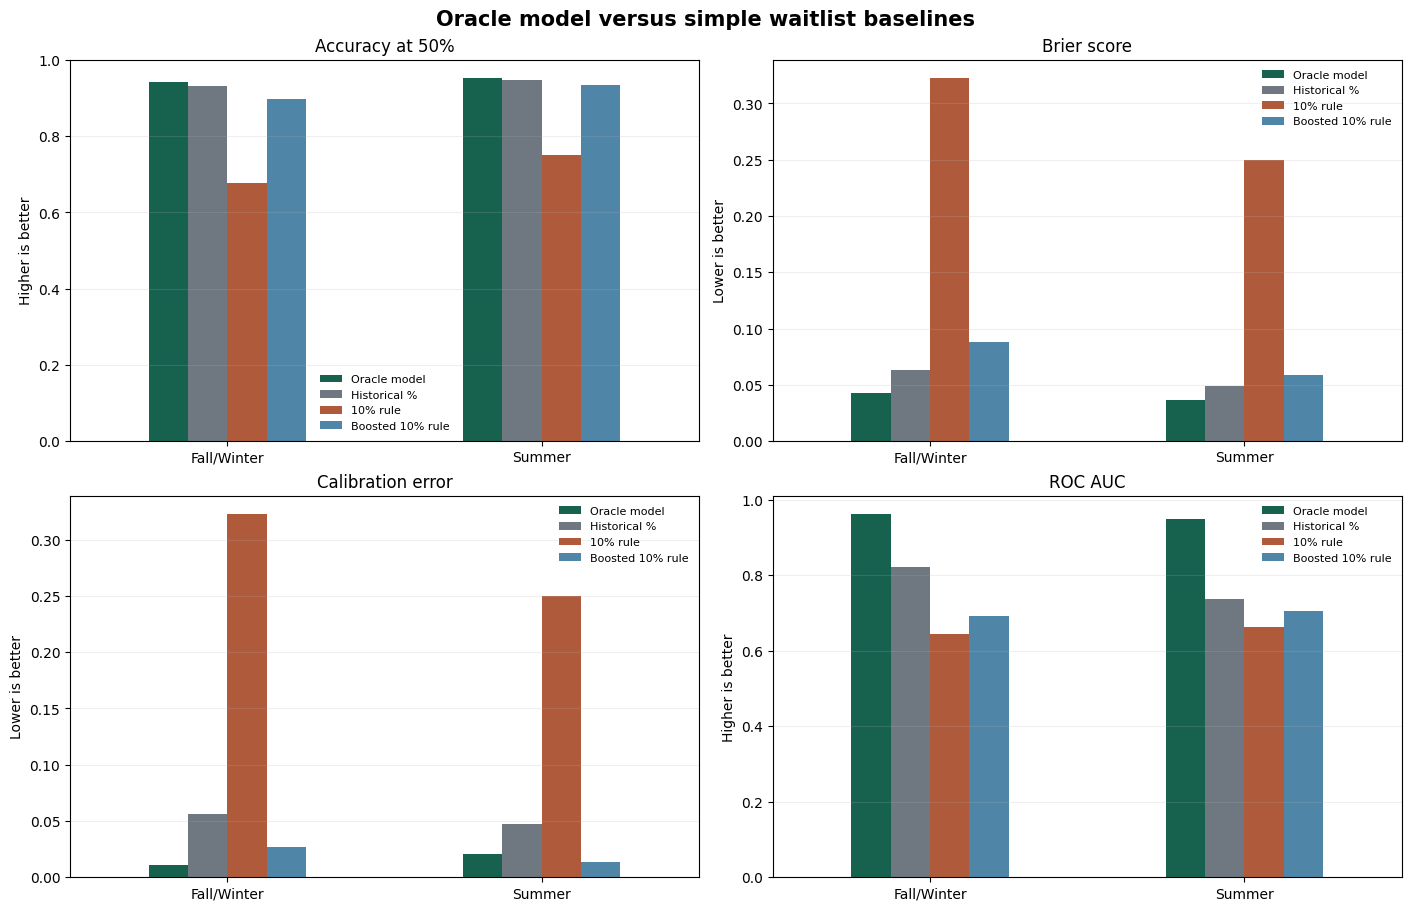

Saved metric benchmark to /student/anfazsha/oracle/docs/assets/model-baseline-benchmark.png


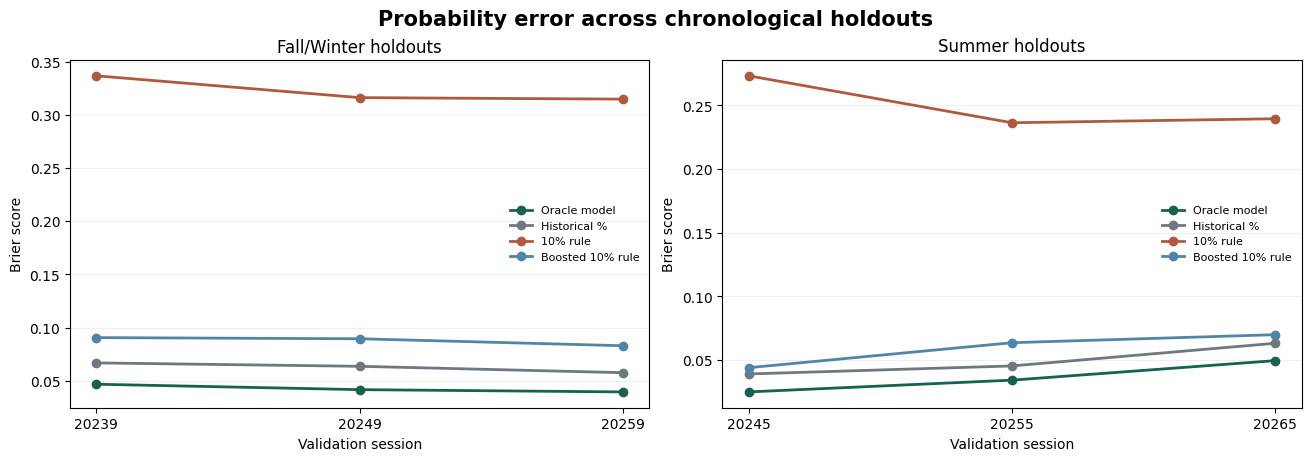

Saved chronological benchmark to /student/anfazsha/oracle/docs/assets/model-chronological-benchmark.png


In [7]:
OUTPUT_ROOT = PROJECT_ROOT / 'docs' / 'assets'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
methods = ['model', 'historical_percentage', '10_percent_rule', 'capacity_only']
labels = {
    'model': 'Oracle model',
    'capacity_only': 'Boosted 10% rule',
    'historical_percentage': 'Historical %',
    '10_percent_rule': '10% rule',
}
colors = {
    'model': '#16624f',
    'capacity_only': '#4f86a8',
    'historical_percentage': '#6f7780',
    '10_percent_rule': '#b05a3c',
}
season_names = {'fall_winter': 'Fall/Winter', 'summer': 'Summer'}
metrics = [
    ('mean_accuracy', 'Accuracy at 50%', 'Higher is better'),
    ('mean_brier', 'Brier score', 'Lower is better'),
    ('mean_ece', 'Calibration error', 'Lower is better'),
    ('mean_auc', 'ROC AUC', 'Higher is better'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for ax, (metric, title, direction) in zip(axes.flat, metrics):
    table = common_summary[metric].unstack('method')[methods]
    table.rename(index=season_names, columns=labels).plot(
        kind='bar', ax=ax, color=[colors[method] for method in methods],
    )
    ax.set(title=title, xlabel='', ylabel=direction)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=.2)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle('Oracle model versus simple waitlist baselines', fontsize=15, fontweight='bold')
benchmark_path = OUTPUT_ROOT / 'model-baseline-benchmark.png'
fig.savefig(benchmark_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved metric benchmark to {benchmark_path}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, season in zip(axes, ['fall_winter', 'summer']):
    season_scores = scores[scores['season'].eq(season) & scores['evaluation_scope'].eq('common_subset')]
    for method in methods:
        line = season_scores[season_scores['method'].eq(method)].sort_values('validation_session')
        ax.plot(
            line['validation_session'], line['brier'], marker='o', linewidth=2,
            label=labels[method], color=colors[method],
        )
    ax.set(title=f'{season_names[season]} holdouts', xlabel='Validation session', ylabel='Brier score')
    ax.grid(axis='y', alpha=.2)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle('Probability error across chronological holdouts', fontsize=15, fontweight='bold')
chronology_path = OUTPUT_ROOT / 'model-chronological-benchmark.png'
fig.savefig(chronology_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved chronological benchmark to {chronology_path}')

## Findings

Across six chronological holdouts, the Oracle and both capacity baselines were scored on every validation row. A separate direct comparison includes the historical percentage only where the complete archive contains a comparable exact-rank lecture. That common subset covers **53.7%** of Fall/Winter validation weight and **40.7%** of Summer validation weight. Accuracy uses a 50% probability cutoff.

### All validation rows

| Season | Method | Accuracy | Brier | ECE | ROC AUC |
|---|---|---:|---:|---:|---:|
| Fall/Winter | Oracle model | **93.5%** | **0.0472** | **0.0118** | **0.9579** |
| Fall/Winter | Literal 10% rule | 65.4% | 0.3455 | 0.3455 | 0.6428 |
| Fall/Winter | Boosted 10% rule | 88.5% | 0.0963 | 0.0268 | 0.6936 |
| Summer | Oracle model | **93.9%** | **0.0463** | 0.0270 | **0.9421** |
| Summer | Literal 10% rule | 71.2% | 0.2877 | 0.2877 | 0.6428 |
| Summer | Boosted 10% rule | 91.1% | 0.0790 | **0.0203** | 0.6783 |

### Common historical-comparison subset

| Season | Method | Accuracy | Brier | ECE | ROC AUC |
|---|---|---:|---:|---:|---:|
| Fall/Winter | Oracle model | **94.1%** | **0.0428** | **0.0105** | **0.9613** |
| Fall/Winter | Historical percentage | 93.2% | 0.0629 | 0.0562 | 0.8211 |
| Fall/Winter | Literal 10% rule | 67.8% | 0.3225 | 0.3225 | 0.6435 |
| Fall/Winter | Boosted 10% rule | 89.7% | 0.0878 | 0.0266 | 0.6921 |
| Summer | Oracle model | **95.2%** | **0.0362** | 0.0208 | **0.9489** |
| Summer | Historical percentage | 94.9% | 0.0491 | 0.0469 | 0.7361 |
| Summer | Literal 10% rule | 75.0% | 0.2498 | 0.2498 | 0.6641 |
| Summer | Boosted 10% rule | 93.5% | 0.0591 | **0.0132** | 0.7043 |

On the common subset, the Oracle reduced mean Brier error by **51.2%** against the boosted 10% rule, **31.8%** against the exact production-history percentage, and **86.7%** against the literal 10% rule in Fall/Winter. The Summer reductions were **38.8%**, **26.4%**, and **85.5%**. The full-holdout table is the overall performance claim; the common subset is only the direct baseline comparison.